Linear Regression

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  
Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='str')
RMSE: 0.06086588041578311


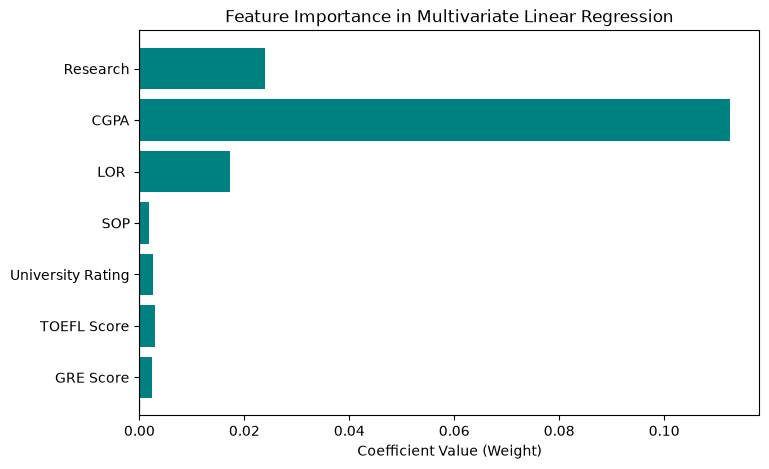

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics



df = pd.read_csv("Admission_Predict.csv")

print(df.head())
print(df.columns)



df.drop("Serial No.", axis=1, inplace=True)


# Separate target variable
y = df["Chance of Admit "]

# Remove target from features
df.drop("Chance of Admit ", axis=1, inplace=True)


# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(
    df,
    y,
    test_size=0.2,
    random_state=42
)


# Create Linear Regression model
lr = LinearRegression()


# Train model
lr.fit(x_train, y_train)


# Make predictions
pred = lr.predict(x_test)


# Calculate RMSE
rmse = np.sqrt(metrics.mean_squared_error(y_test, pred))

print("RMSE:", rmse)


# Feature coefficients
coefficients = lr.coef_
features = df.columns


# Plot coefficients
plt.figure(figsize=(8, 5))

plt.barh(features, coefficients, color="teal")

plt.xlabel("Coefficient Value (Weight)")
plt.title("Feature Importance in Multivariate Linear Regression")

plt.axvline(x=0, color="black", linewidth=0.8)

plt.show()

Logistic Regressionn

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Load dataset
data = pd.read_csv("Social_Network_Ads.csv")
# Encode Gender (Male/Female → 1/0)
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
# Features & target
X = data[['Gender', 'Age', 'EstimatedSalary']].values
y = data['Purchased'].values
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)
# Predictions
y_pred = model.predict(X_test)
# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8875
Confusion Matrix:
 [[50  2]
 [ 7 21]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



Polynomial Regression

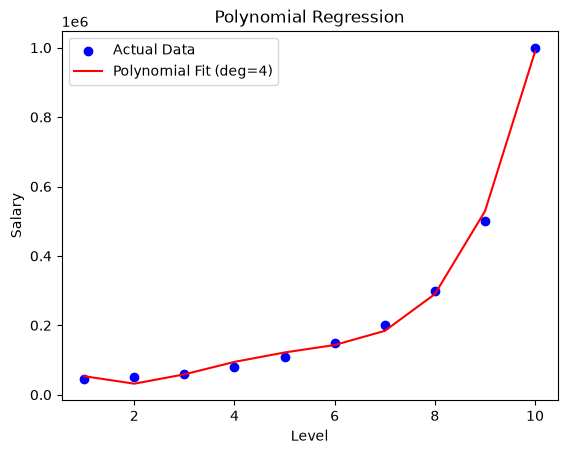

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Load dataset 
data = pd.read_csv("Position_Salaries.csv")

# Independent variable (Level) and dependent variable (Salary)
X = data[["Level"]].values
y = data["Salary"].values
# Polynomial transformation (degree=4 for better curve fitting)
poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X)

# Train polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Predictions
y_pred = poly_model.predict(X_poly)
# Plot results
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, y_pred, color="red", label="Polynomial Fit (deg=4)")
plt.xlabel("Level")
plt.ylabel("Salary")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

